<a href="https://colab.research.google.com/github/snaval29/ML-Projects/blob/main/Experitment_3_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
#Load California Housing Dataset
housing =fetch_california_housing()

In [5]:
#Create Dataframe
data = pd.DataFrame(housing.data, columns=housing.feature_names)
data['Target'] = housing.target

In [6]:
#Basic EDA
# View first few rows
print(data.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


In [7]:
#dataset shape
print("dataset shape",data.shape)

dataset shape (20640, 9)


In [10]:
#Dataset information
print("Data information", data.info)
print(data.describe)

Data information <bound method DataFrame.info of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     

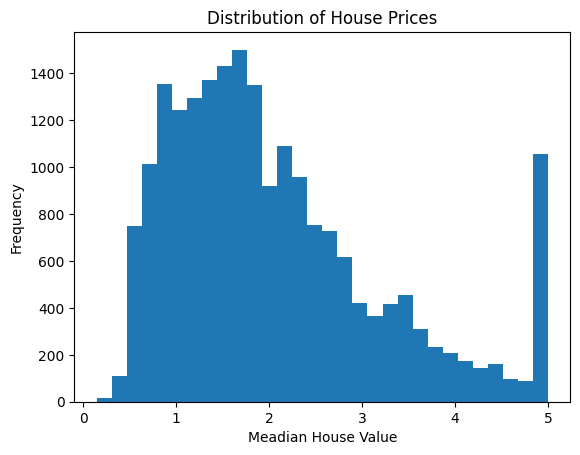

In [9]:
#Histogram of Target variable
plt.figure()
plt.hist(data['Target'], bins=30)
plt.xlabel("Meadian House Value")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

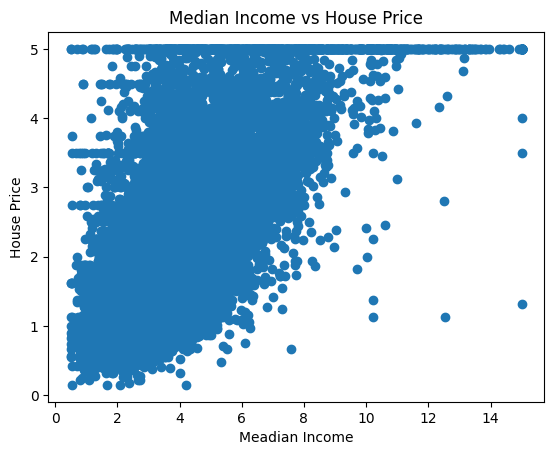

In [11]:
#Bivariate Analysis
#relationship between median income and house price
plt.figure()
plt.scatter(data['MedInc'], data['Target'])
plt.xlabel("Meadian Income")
plt.ylabel("House Price")
plt.title("Median Income vs House Price")
plt.show()

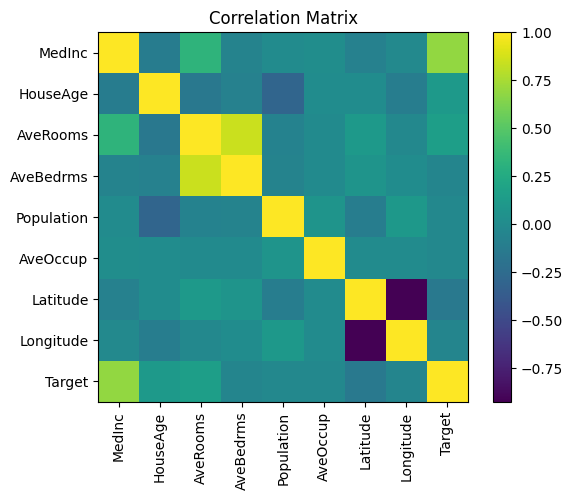

In [12]:
#Correlation Analysis
correlation =data.corr()
plt.figure()
plt.imshow(correlation)
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('Correlation Matrix')
plt.show()

In [14]:
#create dataframe for features
X=pd.DataFrame(housing.data, columns = housing.feature_names)

In [15]:
#Create Target Variable
y = housing.target

In [16]:
#split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
#initialize linear regression model
model=LinearRegression()

In [18]:
#Train the Model
model.fit(X_train, y_train)

LinearRegression()

In [19]:
# Predict house price
y_pred = model.predict(X_test)

In [20]:
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [21]:
# Calculate R2 score
r2=r2_score(y_test, y_pred)

In [22]:
# Display Result
print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.7455813830127764
R2 Score: 0.5757877060324508


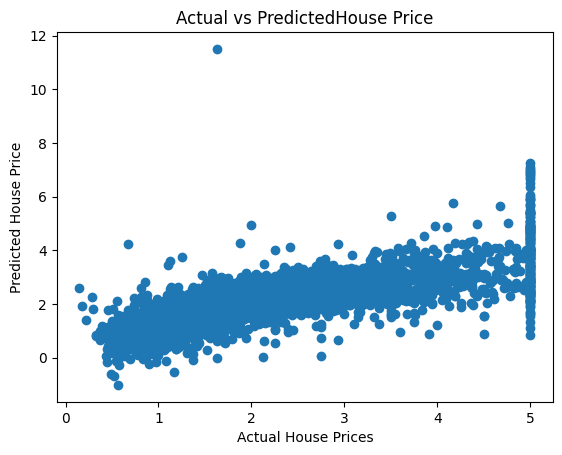

In [23]:
# Actual vs Predicted Values
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Price")
plt.title("Actual vs PredictedHouse Price")
plt.show()

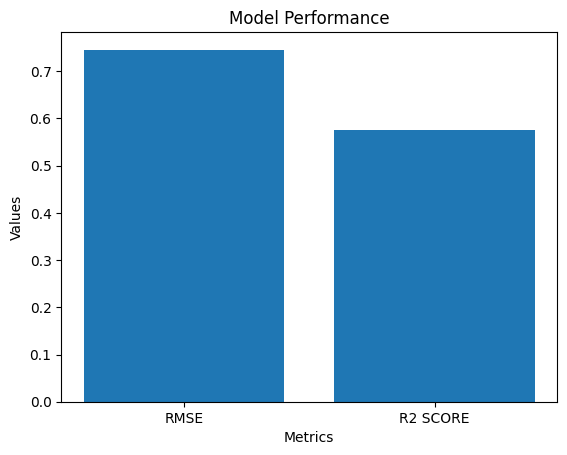

In [24]:
metrics = ['RMSE','R2 SCORE']
values=[rmse,r2]
plt.figure()
plt.bar(metrics,values)
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.title("Model Performance")
plt.show()